
Dataset: Stanford Sentiment Treebank Dataset

Source: https://huggingface.co/datasets/rohith2812/stanford-sentiment-treebank-dataset

Objective: Predict whether a review is Positive(1) or Negative(0)

Models Used:

Logistic Regression: A simple probabilistic model for binary sentiment classification using TF-IDF features.

DistilBERT: A transformer-based model that understands contextual meaning in text and is fine-tuned for sentiment classification.

### Importing Libraries

- os - Used for interacting with the operating system  
- re - Used for regular expressions and pattern matching in text  
- numpy - Used for numerical operations and arrays  
- pandas - Used for data manipulation with DataFrames 
- matplotlib.pyplot - Used for creating plots and visualizations 
- seaborn - Used for statistical visualizations 
- torch - Used for building and training deep learning models  
- nltk -Used for natural language processing tasks 
- stopwords -Used to remove common words from text  
- WordNetLemmatizer - Used to reduce words to their base form
- WordCloud - Used to generate word cloud visualizations 
- TfidfVectorizer - Used to convert text into numerical TF-IDF features 
- LogisticRegression - Used to perform logistic regression classification  
- DistilBertTokenizerFast - Used to tokenize text for DistilBERT 
- DistilBertForSequenceClassification - Used for sequence classification with DistilBERT
- Trainer - Used to train transformer models easily
- TrainingArgument - Used to set training configurations  
- DataCollatorWithPadding - Used to pad sequences in batches for transformers  


In [8]:
# Importing Libraries
import os
import re
import numpy as np
import pandas as pd

# For data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# For Machine Learnign and Deep Learning
import torch

# For Natural Language Processing
import nltk
nltk.download("stopwords")
nltk.download("wordnet")

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from datasets import load_dataset, Dataset

# These are used for metrics & Traditional Modeling
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix # Used to evaluate model performance

# Deep Learning (Transformers)
from transformers import (DistilBertTokenizerFast, DistilBertForSequenceClassification,
                          Trainer, TrainingArguments, DataCollatorWithPadding)


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


### Loading Dataset

In [9]:
# Loading Dataset from Hugging Face
dataset = load_dataset("rohith2812/stanford-sentiment-treebank-dataset")

# Converting train and validation splits to pandas DataFrames
df_train = pd.DataFrame(dataset['train'])
df_val = pd.DataFrame(dataset['validation'])

# Combining Train and Validation
df = pd.concat([df_train, df_val], ignore_index=True)
print(f"Data Shape: {df.shape}")

Repo card metadata block was not found. Setting CardData to empty.


Data Shape: (9645, 2)


### Label Processing

The dataset is prepared for binary sentiment classification:  
- Neutral labels (2) are removed 
- All other labels are converted to 0 (negative) and 1 (positive)

In [10]:
# Label Processing 
initial_count = len(df)

# Removing rows where the label is 2 (neutral sentiment)
df = df[df['label'] != 2].copy()
print(f"Dropped {initial_count - len(df)} neutral rows.")

# This converts remaining labels to binary: 0 and 1
# 0 = negative (original label < 2), 1 = positive (original label > 2)
df['label'] = df['label'].apply(lambda x: 0 if x < 2 else 1)

Dropped 1853 neutral rows.


### Text Cleaning

- The text is cleaned for modeling: neutral characters are removed, stopwords are filtered, and words are lemmatized for traditional models (LR) 
- BERT has separate, minimal cleaning (lowercasing and stripping) because its tokenizer handles punctuation, stopwords, and subword tokenization internally


In [11]:
# Text Cleaning
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

# Text Cleanin for Logistic Regression
def clean_for_lr(text):
    # Converts the text to string, makes it lowercase, and removes all non-alphabetic characters
    text = re.sub(r"[^a-zA-Z\s]", "", str(text).lower())
    # splits the text into words, removes stopwords, lemmatizes each word, and stores the result in tokens
    tokens = [lemmatizer.lemmatize(w) for w in text.split() if w not in stop_words]
    # This joins the tokens back into a single string separated by spaces and returns it
    return " ".join(tokens)

# Text Cleanin for BERT 
def clean_for_bert(text):
    # converts text to string, makes it lowercase, removes spaces
    return str(text).lower().strip()

# Applies cleaning to 'cleaned_text' column
df['text_lr'] = df['cleaned_text'].apply(clean_for_lr)
df['text_bert'] = df['cleaned_text'].apply(clean_for_bert)

# This removes rows where text_lr is empty after cleaning and drops any remaining NaN values
df = df[df['text_lr'].str.strip() != ""].dropna()

### Exploratory Data Analysis (EDA)

The first plot is a word cloud showing the most frequent words in movie reviews 
- This helps visualize common terms and themes in the dataset

The second plot is a class distribution bar chart showing the balance of sentiment labels:  
- 0 - Negative, 1 - Positive.  
- The dataset shows roughly balanced between negative and positive reviews


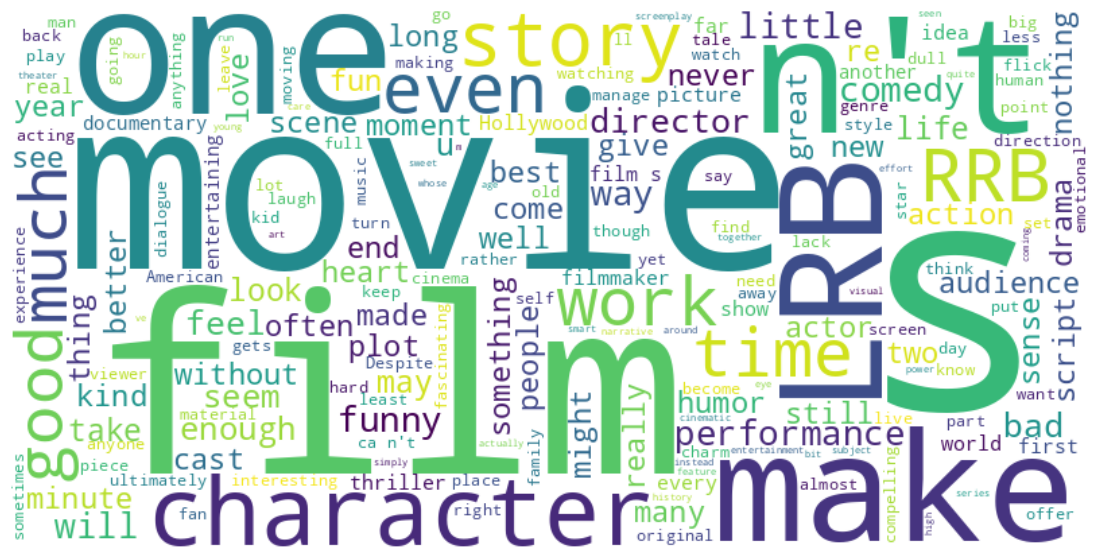

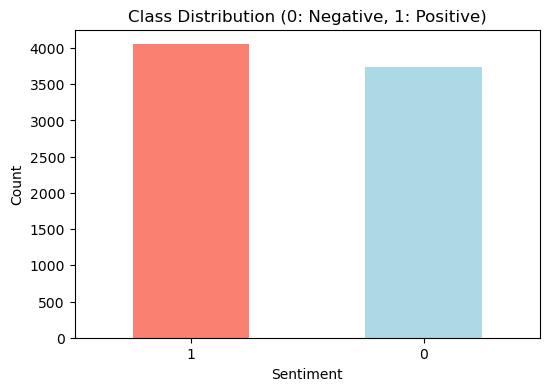

In [17]:
# Exploratory Data Analysis (EDA)

# Word cloud
text_all = " ".join(df['cleaned_text'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_all)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

# Class Distribution
plt.figure(figsize=(6, 4))
df['label'].value_counts().plot(kind='bar', color=['salmon', 'lightblue'])
plt.title('Class Distribution (0: Negative, 1: Positive)')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

### Train test split

In [20]:
# Splits the dataset into training and testing sets
train_df, test_df = train_test_split(
    df, 
    test_size=0.2, # This sets asside 20% of data for testing
    random_state=42, 
    stratify=df['label']
)
print(f"\nTraining Samples: {len(train_df)},  Test Samples: {len(test_df)}")


Training Samples: 6228,  Test Samples: 1557


### Model 1: Logistic Regression

In [21]:
# Logistic Regression

# Initializes a TF-IDF vectorizer with a maximum of 5000 features
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

# Fits the vectorizer on the training text data and transforms it into TF-IDF features
X_train_lr = vectorizer.fit_transform(train_df['text_lr'])
# Transform the test text data into TF-IDF features using the already fitted vectorizer
X_test_lr = vectorizer.transform(test_df['text_lr'])

# this initializes a LR model with a maximum of 1000 iterations
lr_model = LogisticRegression(max_iter=1000)
# Trains the Logistic Regression model on the training features and labels
lr_model.fit(X_train_lr, train_df['label'])
# This uses trained model to predict labels for the test data
lr_preds = lr_model.predict(X_test_lr)

### Evaluation of Logistic Regression
Four key metrics are calculated:
  - Accuracy: Overall correctness of predictions
  - Precision:It shows how reliable the model’s positive predictions are
  - Recall: It shows how well the model captures all actual positive
  - F1 Score: A balance between precision and recall
    
The resulting values give a summary of the model's performance on unseen data

In [22]:
# Evaluation of LR model
lr_metrics = {
   "Accuracy": accuracy_score(test_df['label'], lr_preds),
        "Precision": precision_score(test_df['label'], lr_preds),
        "Recall": recall_score(test_df['label'], lr_preds),
        "F1": f1_score(test_df['label'], lr_preds)
}
lr_metrics



{'Accuracy': 0.7585099550417469,
 'Precision': 0.7577197149643705,
 'Recall': 0.7876543209876543,
 'F1': 0.7723970944309927}

### Model 2: DistilBERT

In [23]:
# pretrained DistilBERT model 
model_name = "distilbert-base-uncased" 

# the tokenizer converts text into token IDs that the model can understand
tokenizer = DistilBertTokenizerFast.from_pretrained(model_name)

In [24]:
# Function to tokenize a batch of text for the DistilBERT model
def tokenize_func(batch):
    return tokenizer(batch['text'], padding='max_length', truncation=True, max_length=128)

In [25]:
# Converts to HF Dataset format
hf_train = Dataset.from_pandas(train_df[['text_bert', 'label']].rename(columns={'text_bert': 'text'}))
hf_test = Dataset.from_pandas(test_df[['text_bert', 'label']].rename(columns={'text_bert': 'text'}))

# 'batched=True' means multiple examples are tokenized at once for efficiency
tok_train = hf_train.map(tokenize_func, batched=True)
tok_test = hf_test.map(tokenize_func, batched=True)

# This allows the datasets to be fed directly into a PyTorch model
tok_train.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
tok_test.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

Map:   0%|          | 0/6228 [00:00<?, ? examples/s]

Map:   0%|          | 0/1557 [00:00<?, ? examples/s]

In [26]:
# Loads the pretrained DistilBERT model 
model = DistilBertForSequenceClassification.from_pretrained(model_name, num_labels=2)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [27]:
# This function calculates evaluation metrics for model's predictions
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    # Return a dictionary of the follwoing evaluation metrics
    return {
        'accuracy': accuracy_score(labels, preds),
        'precision': precision_score(labels, preds),
        'recall': recall_score(labels, preds),
        'f1': f1_score(labels, preds)
    }

#### Training Configuration

- output_dir: ./results - directory to save model checkpoints and results 
- num_train_epochs: 3 - number of times the model will go through the entire training dataset
- per_device_train_batch_size / per_device_eval_batch_size: 16 -  batch size for training and evaluation per device
- learning_rate: 2e-5 -  learning rate for updating the model weights 
- load_best_model_at_end: True - this automatically loads the best model based on evaluation metrics after training 
- weight_decay: 0.01 - regularization to prevent overfitting 



In [28]:
train_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy='epoch',
    save_strategy='epoch',
    learning_rate=2e-5,
    load_best_model_at_end=True,
    weight_decay=0.01,
    report_to="none"
)

#### Setting Up the Trainer

This manages the training and evaluation process:
   
- args: Controls how the training happens 
- train_dataset: Tokenized dataset used to train the model  
- eval_dataset: Tokenized dataset used to evaluate the model’s performance 
- compute_metrics: Function that calculates metrics  after evaluation



In [29]:
# Trainer Setup
trainer = Trainer(
    model=model,
    args=train_args,
    train_dataset=tok_train,
    eval_dataset=tok_test,
    compute_metrics=compute_metrics,
)

### Training Summary by Epoch 
Epoch 1:
  - Training loss was not logged
  - The model performed well on the validation set 

Epoch 2:
  - Training loss decreased to 0.3466 
  - Validation loss increased slightly to 0.3495
  - Accuracy improved to 0.889, F1: 0.891   
  - Despite higher validation loss, the metrics like accuracy and F1 improved  

Epoch 3:
  - Training loss further decreased to 0.1553  
  - Validation loss increased to 0.4117   
  - Metrics were still high, but the increase in validation loss indicates slight overfitting

Overall:
- Even though later epochs had slightly higher validation loss, the best model according to load_best_model_at_end=True is likely selected from Epoch 1, because it had the lowest validation loss
- This shows the model learned quickly and generalizes well, but continued training caused a small rise in validation loss despite high accuracy


In [30]:
# Starts training the model on the training data
trainer.train()

C:\Users\Dell\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.290648,0.880539,0.876812,0.896296,0.886447
2,0.346600,0.349567,0.888889,0.907810,0.875309,0.891263
3,0.155300,0.411703,0.891458,0.897150,0.893827,0.895485


C:\Users\Dell\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
C:\Users\Dell\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


TrainOutput(global_step=1170, training_loss=0.23117307842287244, metrics={'train_runtime': 5786.0709, 'train_samples_per_second': 3.229, 'train_steps_per_second': 0.202, 'total_flos': 618755219122176.0, 'train_loss': 0.23117307842287244, 'epoch': 3.0})

In [32]:
# Evaluates the trained model on the evaluation (test) dataset

# trainer.evaluate() runs the model on the eval dataset and calculates metrics defined in compute_metrics
eval_results = trainer.evaluate()
print(eval_results)

C:\Users\Dell\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'eval_loss': 0.2906479239463806, 'eval_accuracy': 0.8805394990366089, 'eval_precision': 0.8768115942028986, 'eval_recall': 0.8962962962962963, 'eval_f1': 0.8864468864468864, 'eval_runtime': 96.9555, 'eval_samples_per_second': 16.059, 'eval_steps_per_second': 1.011, 'epoch': 3.0}


### Comparision Analysis
The following performance of two models show that:

DistilBERT outperforms Logistic Regression on all metrics
- Accuracy: DistilBERT correctly predicts labels 88%, compared to 75% for Logistic Regression
- Precision: It shows that DistilBERT’s positive predictions are more reliable than LR 
- Recall: DistilBERT captures more actual positive cases  
- F1-Score: DistilBERT has a better overall balance between precision and recall 

In [33]:
# Comparision analysis betweern Logistic Regression and DisilBERT
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "DistilBERT"],
    "Accuracy": [
        lr_metrics["Accuracy"],
        eval_results["eval_accuracy"]
    ],
    "Precision": [
        lr_metrics["Precision"],
        eval_results["eval_precision"]
    ],
    "Recall": [
        lr_metrics["Recall"],
        eval_results["eval_recall"]
    ],
    "F1-Score": [
        lr_metrics["F1"],
        eval_results["eval_f1"]
    ]
})

comparison_df


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.758510,0.757720,0.787654,0.772397
1,DistilBERT,0.880539,0.876812,0.896296,0.886447


### Sample Prediction

In [34]:
# Function to compare prediction between LR and DistilBERT
def compare_predictions(custom_sentence):
    
   # Preprocess the sentence for Logistic Regression and DistilBERT
    lr_input = clean_for_lr(custom_sentence)
    lr_vec = vectorizer.transform([lr_input])
    
    bert_input = clean_for_bert(custom_sentence)

    # Logistic Regression
    lr_pred = lr_model.predict(lr_vec)[0]
    lr_prob = np.max(lr_model.predict_proba(lr_vec))

    # DistilBERT
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

     # Tokenizes the input
    inputs = tokenizer(bert_input, return_tensors="pt", padding=True, truncation=True, max_length=128).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1)
        bert_pred = torch.argmax(probs, dim=1).item()
        bert_prob = probs[0][bert_pred].item()

    # Maps numeric labels to text labels
    label_map = {0: "Negative", 1: "Positive"}

    print(f"\nTarget Sentence: \"{custom_sentence}\"")
    print("-" * 60)
    print(f"{'Model':<20} | {'Cleaned Input':<30} | {'Prediction':<10} | {'Confidence'}")
    print("-" * 60)
    print(f"{'Logistic Regression':<20} | {lr_input} | {label_map[lr_pred]:<10} | {lr_prob:.2%}")
    print(f"{'DistilBERT':<20} | {bert_input} | {label_map[bert_pred]:<10} | {bert_prob:.2%}")

# Test cases with some example sentences
test_cases = [
    "The movie was absolutely fantastic, a true masterpiece.",
    "The plot was slow and the acting was mediocre at best.",
    "It was not as good as I expected, quite a disappointment.", 
    "I've never seen such a brilliant display of storytelling." 
]

for case in test_cases:
    compare_predictions(case)


Target Sentence: "The movie was absolutely fantastic, a true masterpiece."
------------------------------------------------------------
Model                | Cleaned Input                  | Prediction | Confidence
------------------------------------------------------------
Logistic Regression  | movie absolutely fantastic true masterpiece | Positive   | 74.14%
DistilBERT           | the movie was absolutely fantastic, a true masterpiece. | Positive   | 98.37%

Target Sentence: "The plot was slow and the acting was mediocre at best."
------------------------------------------------------------
Model                | Cleaned Input                  | Prediction | Confidence
------------------------------------------------------------
Logistic Regression  | plot slow acting mediocre best | Negative   | 67.97%
DistilBERT           | the plot was slow and the acting was mediocre at best. | Negative   | 96.38%

Target Sentence: "It was not as good as I expected, quite a disappointment."
-

### Hyperparameter Tuning - Logistic Regression

In [35]:
# Performs hyperparameter tuning for Logistic Regression using GridSearchCV
from sklearn.model_selection import GridSearchCV

# param_grid: tests different values of 'C' 
# cv=3: uses 3-fold cross-validation to evaluate each combination
param_grid = {'C': [0.1, 1.0, 10.0]} 
grid_search = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=3)
grid_search.fit(X_train_lr, train_df['label'])

print(f"Best LR Params: {grid_search.best_params_}")

# Makes predictions on the test set using the best Logistic Regression model
tuned_lr_preds = grid_search.predict(X_test_lr)

Best LR Params: {'C': 10.0}


### Logistic Regression: Baseline vs Tuned Model
The tuned model (C=10.0) shows slightly lower performance across all metrics compared to the baseline 
- This suggests that increasing the regularization strength (C) in this case did not improve the model and the original baseline model performs better on the test set
- Overall, the baseline Logistic Regression with C=1.0 remains the better choice for this dataset

In [36]:
# Calculates evaluation metrics for the tuned Logistic Regression model
tuned_lr_metrics = {
    "Accuracy": accuracy_score(test_df['label'], tuned_lr_preds),
    "Precision": precision_score(test_df['label'], tuned_lr_preds),
    "Recall": recall_score(test_df['label'], tuned_lr_preds),
    "F1": f1_score(test_df['label'], tuned_lr_preds)
}

# comparison table to see the effect of tuning
lr_comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1"],
    "Baseline (C=1.0)": [lr_metrics["Accuracy"], lr_metrics["Precision"], lr_metrics["Recall"], lr_metrics["F1"]],
    "Tuned (C=10.0)": [tuned_lr_metrics["Accuracy"], tuned_lr_metrics["Precision"], tuned_lr_metrics["Recall"], tuned_lr_metrics["F1"]]
})

print(lr_comparison)

      Metric  Baseline (C=1.0)  Tuned (C=10.0)
0   Accuracy          0.758510        0.750803
1  Precision          0.757720        0.754217
2     Recall          0.787654        0.772840
3         F1          0.772397        0.763415


### After tuning - DistilBERT

In [37]:
# Tuning DistilBERT Training
from transformers import EarlyStoppingCallback

train_args_tuned = TrainingArguments(
    output_dir='./results_tuned',
    # Increased epochs to allow more learning
    num_train_epochs=5,  
    # Lowered from 2e-5 to slow down overfitting
    learning_rate=1e-5,              
    eval_strategy="epoch",    
    save_strategy="epoch",
    load_best_model_at_end=True,      
    report_to="none"
)

trainer_tuned = Trainer(
    model=model,
    args=train_args_tuned,
    train_dataset=tok_train,
    eval_dataset=tok_test,
    compute_metrics=compute_metrics,
     # Stops training early if validation loss doesn't improve for 1 epoch
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)] # Stop if loss doesn't improve
)

### DistilBERT: Baseline vs Tuned Model

- After tuning, the validation loss increased compared to earlier epochs
- Therefore, 0.88 is selected as best performing accuracy


In [38]:
#  training the tuned DistilBERT model
trainer_tuned.train()

C:\Users\Dell\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.235300,0.477738,0.878613,0.864865,0.908642,0.886213
2,0.156900,0.550473,0.892100,0.897277,0.895062,0.896168


C:\Users\Dell\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


TrainOutput(global_step=1558, training_loss=0.18745731052599454, metrics={'train_runtime': 3736.7818, 'train_samples_per_second': 8.333, 'train_steps_per_second': 1.042, 'total_flos': 412503479414784.0, 'train_loss': 0.18745731052599454, 'epoch': 2.0})

### Visualization - Logistic Regression

Logistic RegressionPerformance 
              precision    recall  f1-score   support

           0       0.76      0.73      0.74       747
           1       0.76      0.79      0.77       810

    accuracy                           0.76      1557
   macro avg       0.76      0.76      0.76      1557
weighted avg       0.76      0.76      0.76      1557



C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


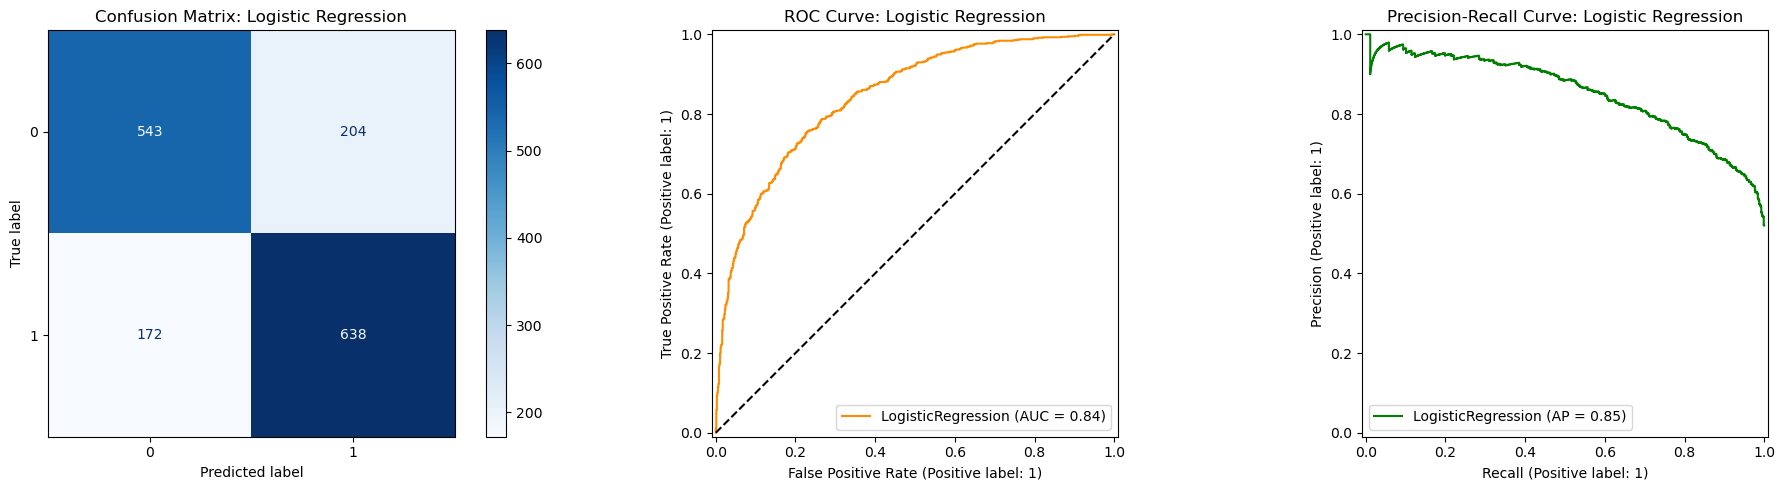

In [39]:
from sklearn.metrics import (ConfusionMatrixDisplay, RocCurveDisplay, 
                             PrecisionRecallDisplay, classification_report, 
                             roc_curve, auc, precision_recall_curve)

# Classification Report
lr_preds = lr_model.predict(X_test_lr)
print("Logistic RegressionPerformance ")
print(classification_report(test_df['label'], lr_preds))

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(lr_model, X_test_lr, test_df['label'], ax=axes[0], cmap='Blues')
axes[0].set_title('Confusion Matrix: Logistic Regression')

# ROC Curve
RocCurveDisplay.from_estimator(lr_model, X_test_lr, test_df['label'], ax=axes[1], color='darkorange')
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_title('ROC Curve: Logistic Regression')

# Precision-Recall Curve
PrecisionRecallDisplay.from_estimator(lr_model, X_test_lr, test_df['label'], ax=axes[2], color='green')
axes[2].set_title('Precision-Recall Curve: Logistic Regression')

plt.tight_layout()
plt.show()

### Visualization - DistilBERT

C:\Users\Dell\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



 DistilBERT Baseline Performance
              precision    recall  f1-score   support

           0       0.90      0.85      0.87       747
           1       0.86      0.91      0.89       810

    accuracy                           0.88      1557
   macro avg       0.88      0.88      0.88      1557
weighted avg       0.88      0.88      0.88      1557



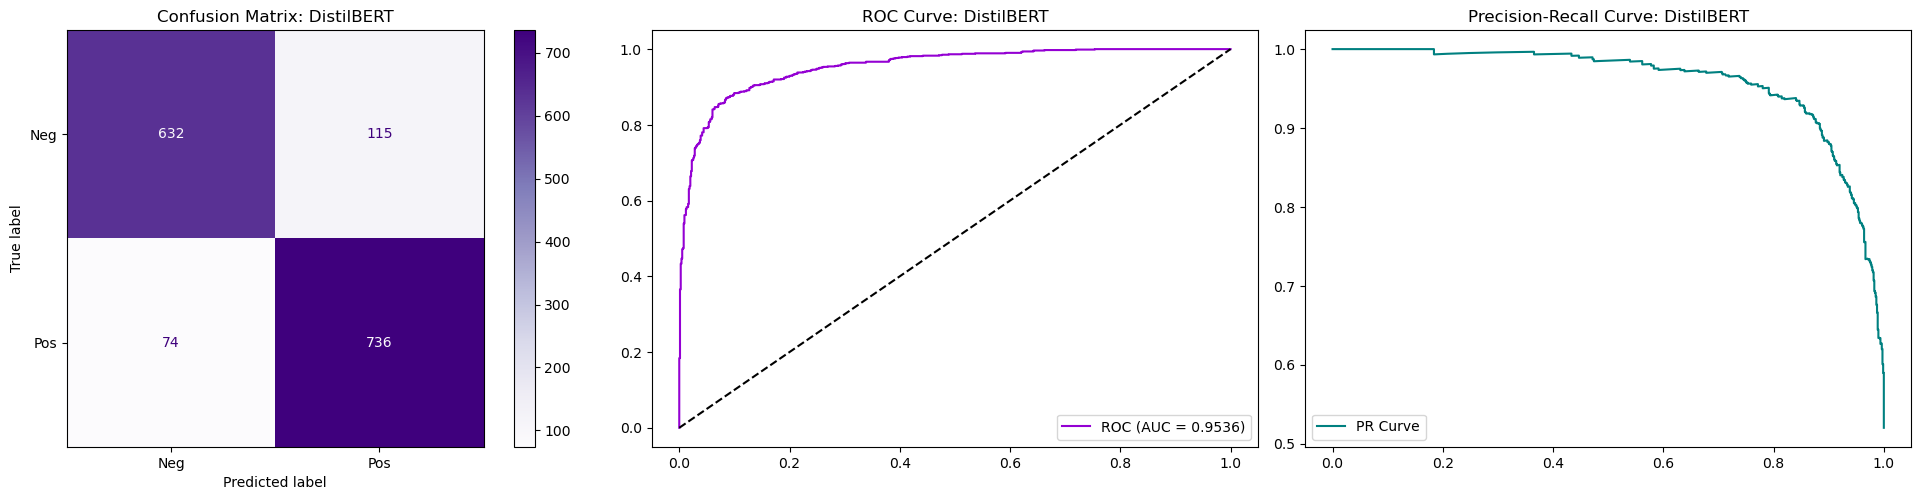

In [40]:

raw_pred = trainer.predict(tok_test)
y_true_bert = raw_pred.label_ids

# Extracts probabilities for ROC/PR curves
y_probs_bert = torch.nn.functional.softmax(torch.tensor(raw_pred.predictions), dim=-1).numpy()[:, 1]
y_pred_bert = np.argmax(raw_pred.predictions, axis=1)

print("\n DistilBERT Baseline Performance")
print(classification_report(y_true_bert, y_pred_bert))

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Confusion Matrix
cm_bert = confusion_matrix(y_true_bert, y_pred_bert)
ConfusionMatrixDisplay(cm_bert, display_labels=['Neg', 'Pos']).plot(ax=axes[0], cmap='Purples')
axes[0].set_title('Confusion Matrix: DistilBERT')

# ROC Curve
fpr, tpr, _ = roc_curve(y_true_bert, y_probs_bert)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='darkviolet', label=f'ROC (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_title('ROC Curve: DistilBERT')
axes[1].legend(loc="lower right")

# Precision-Recall Curve
prec, rec, _ = precision_recall_curve(y_true_bert, y_probs_bert)
axes[2].plot(rec, prec, color='teal', label='PR Curve')
axes[2].set_title('Precision-Recall Curve: DistilBERT')
axes[2].legend(loc="lower left")

plt.tight_layout()
plt.show()